# EXERCISE 1

Consider the data in `oxygen_hydrocarbon_levels.csv`. In this dataframe, y is the purity of oxygen produced in a chemical distillation process, and x is the percentage of hydrocarbons present in the main condenser of the distillation unit.
1. Fit a simple linear regression model to the oxygen purity. 
2. Compute the 95% confidence interval on the slope parameter.
3. Suppose that we are interested in predicting mean oxygen purity when the hydrocarbon level is 1.00%. Compute the 95% confidence interval on the mean response. 
4. Suppose that we are interested in predicting mean oxygen purity when the hydrocarbon level is 1.00%. Compute the 95% prediction interval on the process outcome.

## 1. Fit a simple linear regression model to the oxygen purity. 

In [ ]:
#Import the necessary libraries
import qdatoolkit as qda
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import seaborn as sns
import statsmodels.api as sm

#Import the dataset
data = pd.read_csv('../Data/oxygen_hydrocarbon_levels.csv')

# Inspect the dataset
data.head()

> Let's start by visualizing the data.

In [ ]:
# Plot the Purity (%)
plt.plot(data['Purity (%)'], 'o-', color='blue', label='Original data')
plt.title('Purity (%)')
plt.xlabel('Sample Number')
plt.show()

In [ ]:
# Plot the Hydrocarbon levels
plt.plot(data['Hydrocarbon (%)'], 'o-', color='orange', label='Original data')
plt.title('Hydrocarbon (%)')
plt.xlabel('Sample Number')
plt.show()

> It looks like there is a strong correlation between the two variables. Let's plot the purity of oxygen (y), against the percentage of hydrocarbons (x).

In [ ]:
# Create scatterplot with regression line using seaborn and set axis labels
sns.scatterplot(x='Hydrocarbon (%)', y='Purity (%)', data=data)
# Set axis labels and title
plt.xlabel('Hydrocarbon (%)')
plt.ylabel('Purity (%)')
plt.title('Scatter plot of Hydrocarbon vs Purity')
# Add grid
plt.grid()
# Show the plot
plt.show()

> There is a clear linear correlation between the two variables. Therefore, 'Hydrocarbon (%)' is a promising regressor to predict 'Purity (%)'.


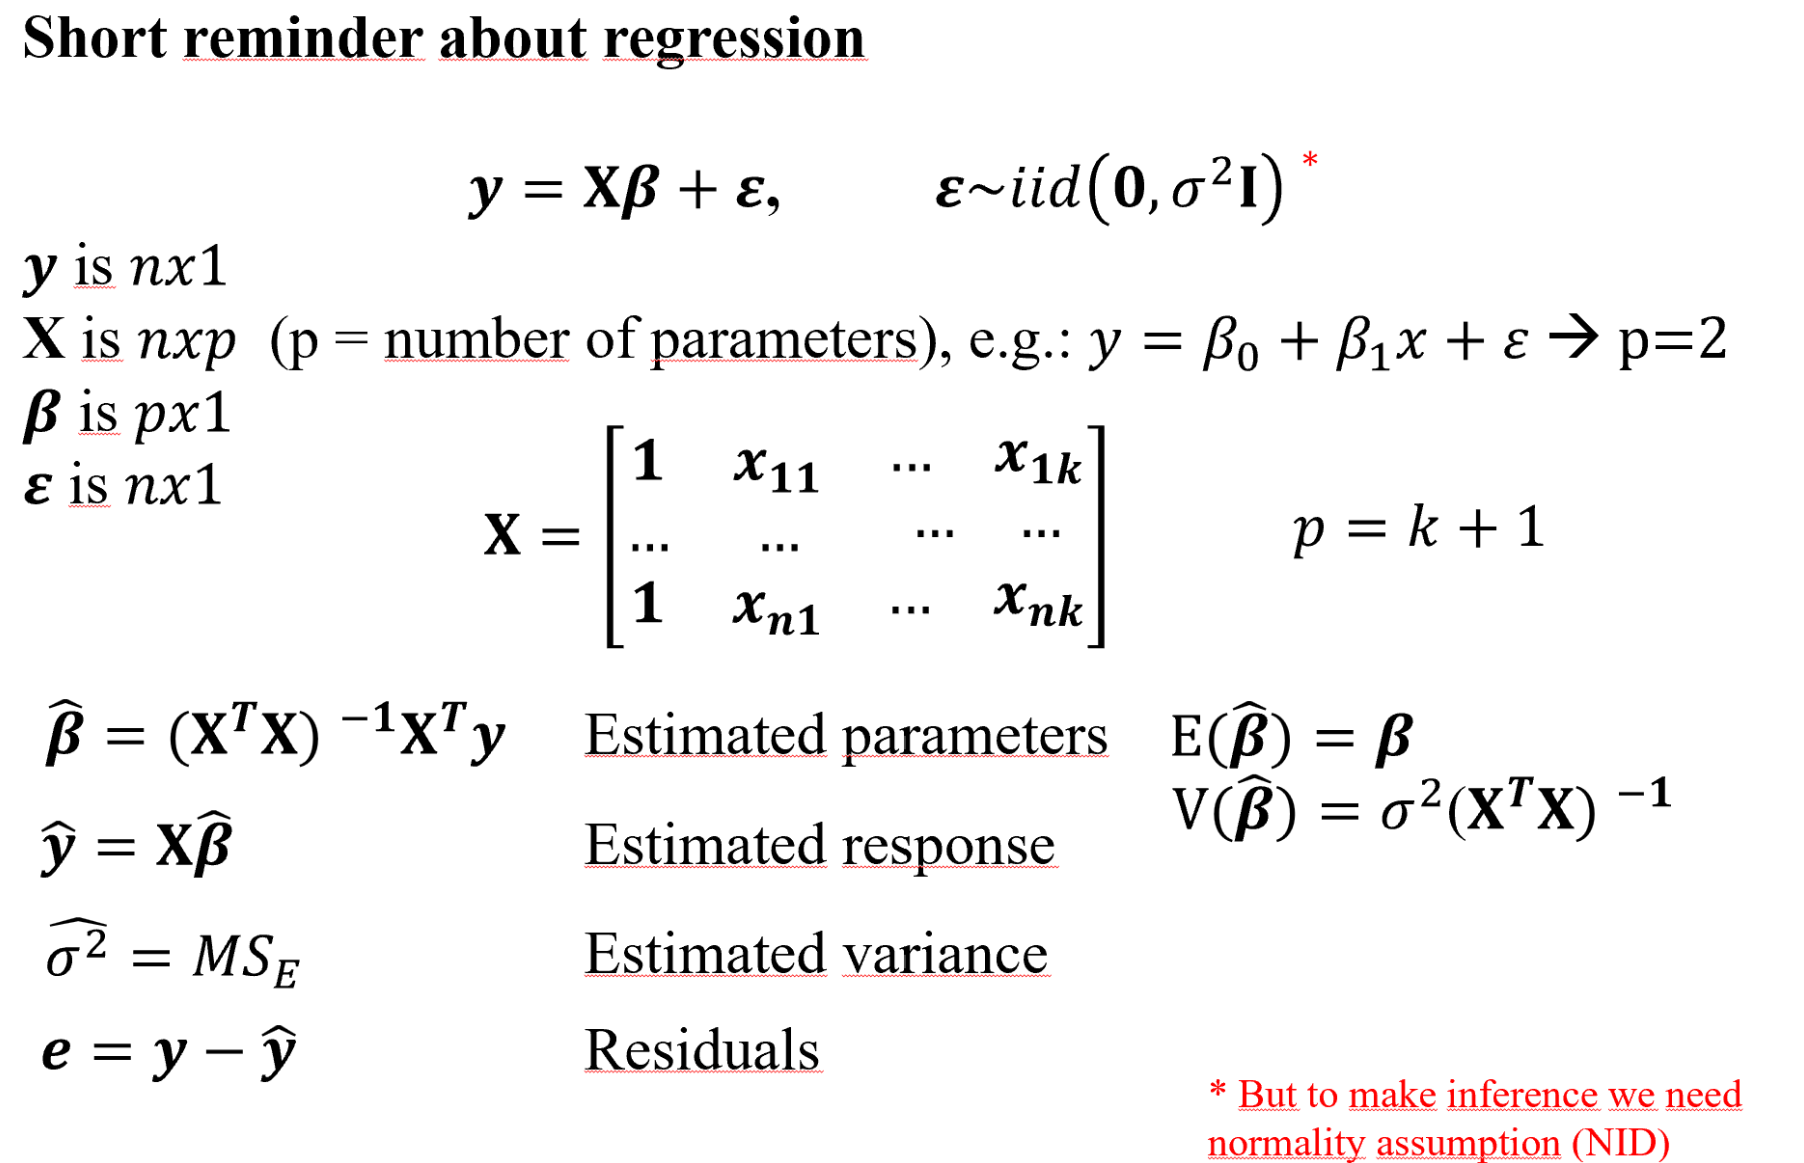

In [ ]:
# Calculate a regression model using hydrocarbon as the independent variable and purity as the dependent variable.
X = data['Hydrocarbon (%)']
X = sm.add_constant(X)  # Adds a constant term to the predictor (it is equivalent to adding a column of ones to the data).
y = data['Purity (%)']

# Fit the regression model
model = sm.OLS(y, X).fit()

In [ ]:
# Print out the statistics of the regression
qda.summary(model)

> ### Test for significance of regression
> - $ H_{0} : \beta_{1} = \beta_{2}  = \beta_{k} =0 $
> - $ H_{1}: \exists \beta_{i} \neq 0 $
>
> Partition of the variance: $ SS_{TOT} = SS_{REG} + SS_{E} $
>
> Degrees of freedom: $ (n-1) = (p-1) + (n-p) $
>
> Definition of the sum of squares:
>
> - $ SS_{TOT} = \sum_{i=1}^n (y_{i}- \bar{y_{i}})^2 $
>
> - $ SS_{REG} = \sum_{i=1}^n (\hat{y_{i}} - \bar{y_{i}})^2 $
>
> - $ SS_{E} = \sum_{i=1}^n (y_{i}- \hat{y_{i}})^2 $
>
> If $H_0$ is true:
> - $ \frac{SS_{REG}}{\sigma^2} \sim \chi^2_{p-1} $
> - $ \frac{SS_{E}}{\sigma^2} \sim \chi^2_{n-p} $
>
> then:
> $$ F_0 = \frac{SS_{REG}/(p-1)}{SS_{E}/(n-p)} = \frac{MS_{REG}}{MS_{E}} \sim F_{p-1,n-p} $$
>
> Reject $H_0$ if: $F_0 > F_{\alpha,p-1,n-p} $
>
> The F-statistic and the corresponding p-value is displayed in the **ANALYSIS OF VARIANCE** table. 

> ### Test for individual coefficients
> - $ H_{0} : \beta_{i} = 0 $
> - $ H_{1} : \beta_{i} \neq 0 $
>
> Test statistic: $T_0 = \frac{\hat{\beta_{i}}}{se(\hat{\beta_{i}})} = \frac{\hat{\beta_{i}}}{\sqrt{\hat{\sigma^2} C_{i}}} $
>
> Where $C_{i}$ is the $i$-th diagonal element of the $(\mathbf{X}^T \mathbf{X})^{-1}$ matrix.
>
> If $H_0$ is true: $T_0 \sim t_{n-p}$
>
> Reject $H_0$ if: $|T_0| > t_{\alpha/2,n-p} $
>
> The t-statistic and the corresponding p-value is displayed in the **COEFFICIENTS** table.


> Both parameters are statistically significant.
>
> Now check on residuals
>
>$ \varepsilon \sim NID  (\mathbf{0}, \sigma^2 \mathbf{I}) $
> 
> They should be normally distributed and independent. 

In [ ]:
# Get the residuals
residuals = model.resid

In [ ]:
# Check the normality of the residuals
_ = qda.Assumptions(residuals).normality()

> We fail to reject the null hypothesis of normality, so we can assume that the residuals are normally distributed.

In [ ]:
# Check the randomness of the residuals
_ = qda.Assumptions(residuals).independence()

> Residuals do not show autocorrelation and we accept the null hypothesis of the runs-test. Assumption on randomness of residuals is accepted.

In [ ]:
s#NORMALITY OF RESIDUALS
fig, axs = plt.subplots(2, 2)
fig.suptitle('Residual Plots')

axs[0,0].set_title('Normal probability plot')
stats.probplot(residuals, dist="norm", plot=axs[0,0])

axs[0,1].set_title('Versus Fits')
axs[0,1].scatter(model.fittedvalues, residuals)

fig.subplots_adjust(hspace=0.5)

axs[1,0].set_title('Histogram')
axs[1,0].hist(residuals)

axs[1,1].set_title('Time series plot')
axs[1,1].plot(np.arange(1, len(residuals)+1), residuals, 'o-')
plt.show()

> - The normal probability plot (top left) shows a normal distribution of the residuals. 
> - The histogram (bottom left) confirms normality. 
> - On top right, residuals versus fits are shown. 
> - The bottom right panel shows the time series plot of the residuals. 

In [ ]:
# plot the original data and fitted values
plt.plot(data['Purity (%)'], 'o-', color='blue', label='Original data')
plt.plot(model.fittedvalues, 's--', color='red', label='Fitted values')
plt.title('Original data vs Fitted values')
plt.xlabel('Index')
plt.ylabel('Data')
plt.legend()
plt.show()

## 2. Compute the 95% confidence interval on the slope parameter.

> **Confidence intervals**
>
> If we define an interval
> $$L \le \theta \le U$$ 
> such that
> $$P(\theta \in [L, U]) = 1 - \alpha$$
> $[L, U]$ is called a $100(1 - \alpha)\%$ confidence interval for $\theta$.
>
> *Interpretation: if, in repeated random samples, we compute the confidence interval for $\theta$, then $100(1 - \alpha)\%$ of the intervals will contain the true value of $\theta$.*
>
> Remember that if: 
> $$X \sim N(\mu, \sigma^2) $$
> then:
> $$ \frac{X - \mu}{s} \sim t_{n-1}$$

You can access the values of the estimated coefficients and their standard errors from the  `RegressionResult` object that is the output of the `fit()` method.

In [ ]:
# The RegressionResult object was stored in the variable model
# Get the estimated coefficient
beta1 = model.params['Hydrocarbon (%)']
print('The estimated coefficient beta1 is %.3f' % beta1)

se_beta1 = model.bse['Hydrocarbon (%)']
print('The standard error of the estimated coefficient beta1 is %.3f' % se_beta1)

alpha = 0.05
n = len(data)
t_alpha2 = stats.t.ppf(1-alpha/2, n-2)

CI_beta1 = [beta1 - t_alpha2*se_beta1, beta1 + t_alpha2*se_beta1]

print('The confidence interval for beta1 is [%.3f, %.3f]' % (CI_beta1[0], CI_beta1[1]))

> Alternatively, you can use the `conf_int()` method to compute the confidence interval on the coefficients of the model for any specified value of alpha.

In [ ]:
# Calculate the confidence interval
CI_beta1 = model.conf_int(alpha=0.05).loc['Hydrocarbon (%)']
print('The confidence interval for beta1 is [%.3f, %.3f]' % (CI_beta1[0], CI_beta1[1]))

## 3. Suppose that we are interested in predicting mean oxygen purity when the hydrocarbon level is 1.00%. Compute the 95% confidence interval on the mean response. 

The confidence interval for the mean response is given by:
$$\hat{y} \pm t_{\alpha/2,n-p} \cdot \sqrt{\hat{\sigma}^2_{\varepsilon} \left(\frac{1}{n} + \frac{(x - \bar{x})^2}{(n-1)s_x^2}\right)}$$

where $\hat{y}$ is the predicted value of the response variable, $t_{\alpha/2,n-p}$ is the t-value for the desired confidence level and degrees of freedom, $\hat{\sigma}^2_{\varepsilon}$ is the estimated variance of the residuals, $n$ is the sample size, $x$ is the value of the predictor variable for which we want to make a prediction, $\bar{x}$ is the mean of the predictor variable, and $s_x^2$ is the sample variance of the predictor variable.

In [ ]:
Xbar = data['Hydrocarbon (%)'].mean()  # sample mean of the regressor
S2_X = data['Hydrocarbon (%)'].var()   # sample variance of the regressor

p = len(model.model.exog_names)     # number of regressors
S2_Y = np.var(model.resid, ddof=p)  # sample variance of residuals

alpha = 0.05
t_alpha2 = stats.t.ppf(1-alpha/2, n-p)

In [ ]:
# predict the new outcome using the regression model
x_new = 1
print('X_new = %.3f' % x_new)

#Get the predicted value
Yhat = model.predict([1,x_new])
print('Predicted value = %.3f' % Yhat)

In [ ]:
# Calculate the confidence interval
CI = [Yhat - t_alpha2*np.sqrt(S2_Y*(1/n + ((x_new - Xbar)**2)/((n-1)*S2_X))),
        Yhat + t_alpha2*np.sqrt(S2_Y*(1/n + ((x_new - Xbar)**2)/((n-1)*S2_X)))]
print('The confidence interval for the mean response is [%.3f, %.3f]' % (CI[0], CI[1]))

## 4. Suppose that we are interested in predicting mean oxygen purity when the hydrocarbon level is 1%. Compute the 95% prediction interval on the process outcome. 

The confidence interval for the mean response is given by:
$$\hat{y} \pm t_{\alpha/2,n-p} \cdot \sqrt{\hat{\sigma}^2_{\varepsilon} \left(1+\frac{1}{n} + \frac{(x - \bar{x})^2}{(n-1)s_x^2}\right)}$$

where $\hat{y}$ is the predicted value of the response variable, $t_{\alpha/2,n-p}$ is the t-value for the desired confidence level and degrees of freedom, $\hat{\sigma}^2_{\varepsilon}$ is the estimated variance of the residuals, $n$ is the sample size, $x$ is the value of the predictor variable for which we want to make a prediction, $\bar{x}$ is the mean of the predictor variable, and $s_x^2$ is the sample variance of the predictor variable.

In [ ]:
# predict the new outcome using the regression model
x_new = 1
print('X_new = %.3f' % x_new)

#Get the predicted value
Yhat = model.predict([1,x_new])
print('Predicted value = %.3f' % Yhat)

In [ ]:
# Calculate the PREDICTION interval
PI = [Yhat - t_alpha2*np.sqrt(S2_Y*(1 + 1/n + ((x_new - Xbar)**2)/((n-1)*S2_X))),
        Yhat + t_alpha2*np.sqrt(S2_Y*(1 + 1/n + ((x_new - Xbar)**2)/((n-1)*S2_X)))]

print('The prediction interval for the next value is [%.5f, %.5f]' % (PI[0], PI[1]))

Alternatively, you can use the `get_prediction()` method to compute the prediction for the next process outcome and the associated confidence and prediction intervals.

In [ ]:
# compute the prediction interval
prediction_df = model.get_prediction([1,x_new]).summary_frame(alpha=0.05)
print(prediction_df)

To visualize the prediction interval, you can evaluate the bounds across the range of the regressor using the `get_prediction()` method.

In [ ]:
# get the range of values for the regressor
x_range = np.linspace(data['Hydrocarbon (%)'].min(), data['Hydrocarbon (%)'].max(), 100)

# add a constant to the regressor
x_range = sm.add_constant(x_range)

# get the prediction interval for each value of the regressor
prediction_df = model.get_prediction(x_range).summary_frame(alpha=0.05)

# plot the data and the intervals
plt.plot(data['Hydrocarbon (%)'], data['Purity (%)'], 'o', color='blue', label='Original data')
plt.plot(x_range[:,1], prediction_df['mean'], '--', color='red', label='Fitted values')
plt.fill_between(x_range[:,1], prediction_df['obs_ci_lower'], prediction_df['obs_ci_upper'], color='green', alpha=0.2)
plt.fill_between(x_range[:,1], prediction_df['mean_ci_lower'], prediction_df['mean_ci_upper'], color='red', alpha=0.2)
plt.title('Hydrocarbon (%) vs Purity (%) with Prediction Intervals')
plt.xlabel('Hydrocarbon (%)')
plt.ylabel('Purity (%)')
plt.show()